# Minimum Wage and Unemployment in Europe

## Project Overview
This project analyzes the relationship between minimum wage levels and unemployment rates across European countries from 2003 to 2025.

## Data Sources
- Minimum wage data: Eurostat API (earn_mw_cur)
- Unemployment rate data: Eurostat API (une_rt_a)
- Exchange rate data: Eurostat API (ert_bil_eur_a)

## Research Question
Does a higher minimum wage lead to lower unemployment rates in Europe?

## Main Finding
A statistically significant negative correlation exists between minimum wage and unemployment rate (slope = -0.003, R² = 0.12, p < 0.05).


## 1. Data Collection
Download minimum wage, unemployment rate, and exchange rate data from the Eurostat API.


In [ ]:
import requests

def test_eurostat_api(dataset_code, label):
    """Test if a Eurostat dataset is accessible via API"""
    url = f"https://ec.europa.eu/eurostat/api/dissemination/statistics/1.0/data/{dataset_code}?format=JSON&lang=EN"

    try:
        response = requests.get(url, timeout=30)
        if response.status_code == 200:
            data = response.json()
            dimensions = list(data['dimension'].keys())
            n_values = len(data['value'])
            print(f"OK {label} ({dataset_code})")
            print(f"   -> Successfully downloaded, {n_values} data points in total")
            print(f"   -> Dimensions: {dimensions}\n")
            return True
        else:
            print(f"FAILED {label} ({dataset_code}): HTTP {response.status_code}\n")
            return False
    except Exception as e:
        print(f"FAILED {label} ({dataset_code}): {e}\n")
        return False


print("=== Eurostat API Access Verification ===\n")

results = []
results.append(test_eurostat_api("earn_mw_cur", "Minimum Wage Data"))
results.append(test_eurostat_api("lfsi_emp_a",  "Employment Rate Data"))
results.append(test_eurostat_api("nama_10_gdp", "GDP Data"))
results.append(test_eurostat_api("une_rt_a",    "Unemployment Rate Data"))

print(f"Verification result: {sum(results)}/4 datasets accessible")


=== Eurostat API Access Verification ===

OK Minimum Wage Data (earn_mw_cur)
   -> Successfully downloaded, 4484 data points in total
   -> Dimensions: ['freq', 'currency', 'geo', 'time']

OK Employment Rate Data (lfsi_emp_a)
   -> Successfully downloaded, 45552 data points in total
   -> Dimensions: ['freq', 'indic_em', 'sex', 'age', 'unit', 'geo', 'time']

OK GDP Data (nama_10_gdp)
   -> Successfully downloaded, 1112429 data points in total
   -> Dimensions: ['freq', 'unit', 'na_item', 'geo', 'time']

OK Unemployment Rate Data (une_rt_a)
   -> Successfully downloaded, 39669 data points in total
   -> Dimensions: ['freq', 'age', 'unit', 'sex', 'geo', 'time']

Verification result: 4/4 datasets accessible


In [ ]:
import pandas as pd
def eurostat_to_dataframe(dataset_code):
    url = f"https://ec.europa.eu/eurostat/api/dissemination/statistics/1.0/data/{dataset_code}?format=JSON&lang=EN"
    response = requests.get(url, timeout=30)
    data = response.json()

    dims = data['dimension']
    dim_names = list(dims.keys())

    dim_indices = []
    for dim in dim_names:
        categories = dims[dim]['category']
        index_map = {v: k for k, v in categories['index'].items()}
        dim_indices.append(index_map)

    rows = []
    for pos_str, value in data['value'].items():
        pos = int(pos_str)
        coords = []
        for i in range(len(dim_names) - 1, -1, -1):
            size = len(dim_indices[i])
            coords.insert(0, dim_indices[i][pos % size])
            pos //= size
        rows.append(coords + [value])

    df = pd.DataFrame(rows, columns=dim_names + ['value'])
    return df

mw_df = eurostat_to_dataframe("earn_mw_cur")
print(mw_df.head(10))
print("Shape:", mw_df.shape)


  freq currency geo     time  value
0    S      EUR  AL  1999-S2   45.0
1    S      EUR  AL  2000-S1   47.0
2    S      EUR  AL  2000-S2   52.0
3    S      EUR  AL  2001-S1   53.0
4    S      EUR  AL  2001-S2   60.0
5    S      EUR  AL  2002-S1   63.0
6    S      EUR  AL  2002-S2   68.0
7    S      EUR  AL  2003-S1   67.0
8    S      EUR  AL  2003-S2   74.0
9    S      EUR  AL  2004-S1   75.0
Shape: (4484, 5)


## 2. Data Cleaning
Clean and standardize the data, convert all currencies to EUR, and merge into a panel dataset.


In [ ]:

mw_clean = mw_df[mw_df['freq'] == 'S'].copy()
mw_clean = mw_clean[mw_clean['time'].str.endswith('S1')].copy()
mw_clean['year'] = mw_clean['time'].str[:4].astype(int)
mw_clean = mw_clean[['geo', 'year', 'value']].rename(columns={'value': 'min_wage'})

print(mw_clean.head(10))
print("Shape:", mw_clean.shape)


   geo  year  min_wage
1   AL  2000      47.0
3   AL  2001      53.0
5   AL  2002      63.0
7   AL  2003      67.0
9   AL  2004      75.0
11  AL  2005      85.0
13  AL  2006      96.0
15  AL  2007     113.0
17  AL  2008     131.0
19  AL  2009     137.0
Shape: (2278, 3)


In [ ]:

une_df = eurostat_to_dataframe("une_rt_a")
print(une_df.head())
print("Dimensions:", une_df.columns.tolist())


  freq     age    unit sex geo  time  value
0    A  Y15-24  PC_ACT   F  AT  2009   10.5
1    A  Y15-24  PC_ACT   F  AT  2010    9.8
2    A  Y15-24  PC_ACT   F  AT  2011    9.5
3    A  Y15-24  PC_ACT   F  AT  2012    9.6
4    A  Y15-24  PC_ACT   F  AT  2013   10.4
Dimensions: ['freq', 'age', 'unit', 'sex', 'geo', 'time', 'value']


In [ ]:
une_clean = une_df[
    (une_df['age'] == 'TOTAL') &
    (une_df['sex'] == 'T') &
    (une_df['unit'] == 'PC_ACT')
].copy()

une_clean['year'] = une_clean['time'].astype(int)
une_clean = une_clean[['geo', 'year', 'value']].rename(columns={'value': 'unemployment_rate'})

print(une_clean.head(10))
print("Shape:", une_clean.shape)


Empty DataFrame
Columns: [geo, year, unemployment_rate]
Index: []
Shape: (0, 3)


In [ ]:
print("age_all_value:", une_df['age'].unique())
print("sex_all_value:", une_df['sex'].unique())
print("unit_all_value:", une_df['unit'].unique())


age_all_value: ['Y15-24' 'Y15-29' 'Y15-74' 'Y20-64' 'Y25-54' 'Y25-74' 'Y55-74']
sex_all_value: ['F' 'M' 'T']
unit_all_value: ['PC_ACT' 'PC_POP' 'THS_PER']


In [ ]:
une_clean = une_df[
    (une_df['age'] == 'Y15-74') &
    (une_df['sex'] == 'T') &
    (une_df['unit'] == 'PC_ACT')
].copy()

une_clean['year'] = une_clean['time'].astype(int)
une_clean = une_clean[['geo', 'year', 'value']].rename(columns={'value': 'unemployment_rate'})

print(une_clean.head(10))
print("Shape:", une_clean.shape)


      geo  year  unemployment_rate
12605  AT  2009                5.7
12606  AT  2010                5.2
12607  AT  2011                4.9
12608  AT  2012                5.2
12609  AT  2013                5.7
12610  AT  2014                6.0
12611  AT  2015                6.1
12612  AT  2016                6.5
12613  AT  2017                5.9
12614  AT  2018                5.2
Shape: (634, 3)


In [ ]:

panel = pd.merge(mw_clean, une_clean, on=['geo', 'year'], how='inner')

print(panel.head(10))
print("Shape:", panel.shape)
print("The_amount_of_country:", panel['geo'].nunique())
print("Year_range:", panel['year'].min(), "-", panel['year'].max())


  geo  year  min_wage  unemployment_rate
0  BE  2009    1388.0                8.0
1  BE  2010    1388.0                8.4
2  BE  2011    1415.0                7.2
3  BE  2012    1444.0                7.6
4  BE  2013    1502.0                8.6
5  BE  2014    1502.0                8.7
6  BE  2015    1502.0                8.7
7  BE  2016    1502.0                7.9
8  BE  2017    1532.0                7.2
9  BE  2018    1563.0                6.0
Shape: (1238, 4)
The_amount_of_country: 26
Year_range: 2003 - 2025


In [ ]:

er_df = eurostat_to_dataframe("ert_bil_eur_a")
print(er_df.head())
print("dimension:", er_df.columns.tolist())
print("currency_value:", er_df['currency'].unique() if 'currency' in er_df.columns else "None")


  freq statinfo unit currency  time    value
0    A      AVG  NAC      AED  2001  3.27810
1    A      AVG  NAC      AED  2002  3.49425
2    A      AVG  NAC      AED  2003  4.19886
3    A      AVG  NAC      AED  2004  4.58488
4    A      AVG  NAC      AED  2005  4.55976
dimension: ['freq', 'statinfo', 'unit', 'currency', 'time', 'value']
currency_value: ['AED' 'AFN' 'ALL' 'AMD' 'AOA' 'ARS' 'AUD' 'AWG' 'AZN' 'BAM' 'BBD' 'BDT'
 'BHD' 'BIF' 'BMD' 'BND' 'BOB' 'BRL' 'BSD' 'BTN' 'BWP' 'BYN' 'BZD' 'CAD'
 'CDF' 'CHF' 'CLP' 'CNY' 'COP' 'CRC' 'CUP' 'CVE' 'CZK' 'DJF' 'DKK' 'DOP'
 'DZD' 'EGP' 'ERN' 'ETB' 'FJD' 'FKP' 'GBP' 'GEL' 'GHS' 'GIP' 'GMD' 'GNF'
 'GTQ' 'GYD' 'HKD' 'HNL' 'HTG' 'HUF' 'IDR' 'ILS' 'INR' 'IQD' 'IRR' 'ISK'
 'JMD' 'JOD' 'JPY' 'KES' 'KGS' 'KHR' 'KMF' 'KRW' 'KWD' 'KYD' 'KZT' 'LAK'
 'LBP' 'LKR' 'LRD' 'LSL' 'LYD' 'MAD' 'MDL' 'MGA' 'MKD' 'MMK' 'MNT' 'MOP'
 'MRU' 'MUR' 'MVR' 'MWK' 'MXN' 'MYR' 'MZN' 'NAD' 'NGN' 'NIO' 'NOK' 'NPR'
 'NZD' 'OMR' 'PAB' 'PEN' 'PGK' 'PHP' 'PKR' 'PLN' 'PYG' 'QAR' 

In [ ]:

currencies_needed = ['CZK', 'HUF', 'MKD', 'RSD', 'TRY']

er_clean = er_df[
    (er_df['currency'].isin(currencies_needed)) &
    (er_df['statinfo'] == 'AVG') &
    (er_df['unit'] == 'NAC')
].copy()

er_clean['year'] = er_clean['time'].astype(int)
er_clean = er_clean[['currency', 'year', 'value']].rename(columns={'value': 'exchange_rate'})

print(er_clean.head(10))
print("Shape:", er_clean.shape)


    currency  year  exchange_rate
871      CZK  1993         34.169
872      CZK  1994         34.151
873      CZK  1995         34.696
874      CZK  1996         34.457
875      CZK  1997         35.930
876      CZK  1998         36.049
877      CZK  1999         36.884
878      CZK  2000         35.599
879      CZK  2001         34.068
880      CZK  2002         30.804
Shape: (173, 3)


In [ ]:

geo_to_currency = {
    'CZ': 'CZK',
    'HU': 'HUF',
    'MK': 'MKD',
    'RS': 'RSD',
    'TR': 'TRY'
}

panel['currency'] = panel['geo'].map(geo_to_currency)


panel_with_er = pd.merge(panel, er_clean, on=['currency', 'year'], how='left')

panel_with_er['min_wage_eur'] = panel_with_er.apply(
    lambda row: row['min_wage'] / row['exchange_rate']
    if pd.notna(row['exchange_rate'])
    else row['min_wage'],
    axis=1
)

panel_final = panel_with_er[['geo', 'year', 'min_wage_eur', 'unemployment_rate']].copy()

print(panel_final.head(10))
print("Shape:", panel_final.shape)


  geo  year  min_wage_eur  unemployment_rate
0  BE  2009        1388.0                8.0
1  BE  2010        1388.0                8.4
2  BE  2011        1415.0                7.2
3  BE  2012        1444.0                7.6
4  BE  2013        1502.0                8.6
5  BE  2014        1502.0                8.7
6  BE  2015        1502.0                8.7
7  BE  2016        1502.0                7.9
8  BE  2017        1532.0                7.2
9  BE  2018        1563.0                6.0
Shape: (1238, 4)


## 3. Visualization
Visualize the relationship between minimum wage and unemployment rate across countries and regions.


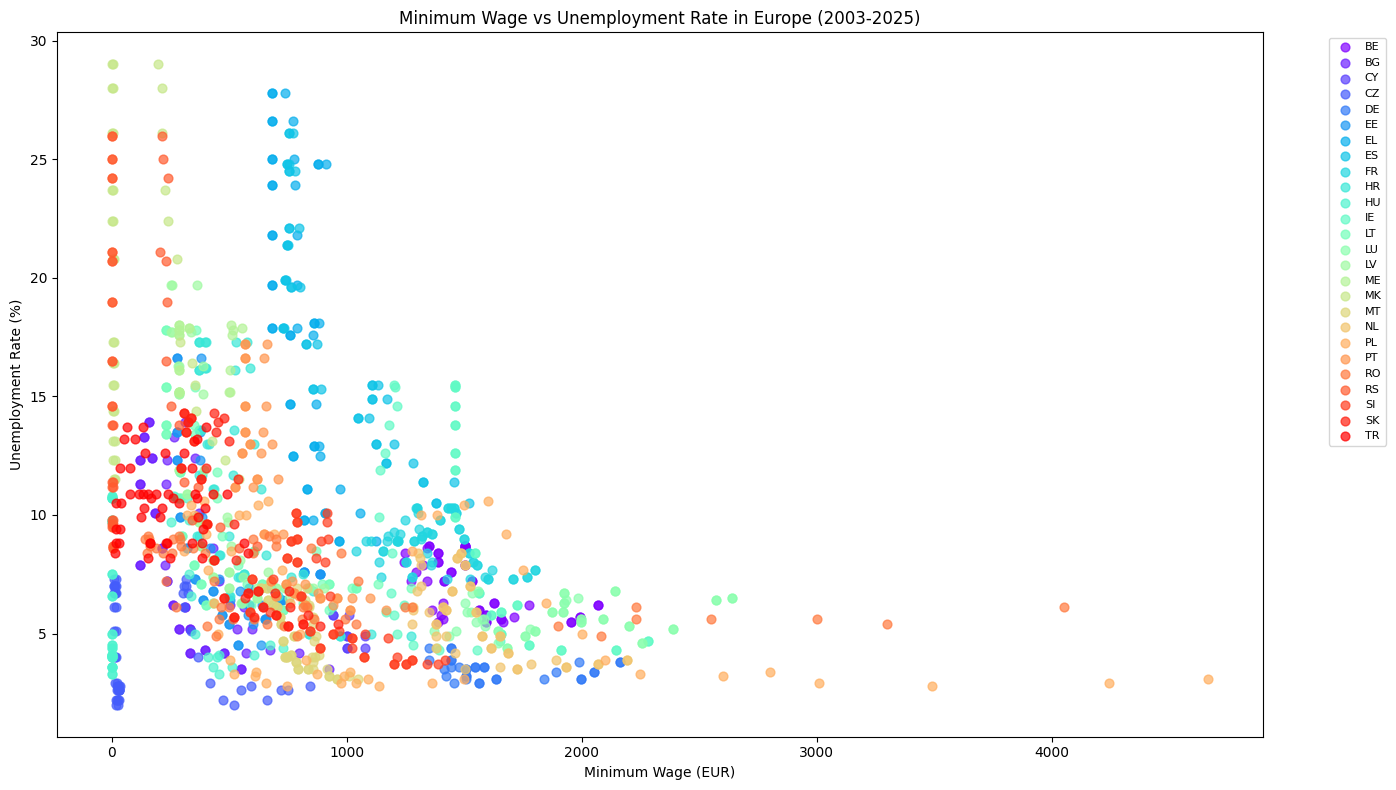

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

fig, ax = plt.subplots(figsize=(14, 8))

countries = sorted(panel_final['geo'].unique())
colors = cm.rainbow(np.linspace(0, 1, len(countries)))

for i, country in enumerate(countries):
    data = panel_final[panel_final['geo'] == country]
    ax.scatter(data['min_wage_eur'], data['unemployment_rate'],
               label=country, color=colors[i], alpha=0.7, s=40)

ax.set_xlabel('Minimum Wage (EUR)')
ax.set_ylabel('Unemployment Rate (%)')
ax.set_title('Minimum Wage vs Unemployment Rate in Europe (2003-2025)')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()


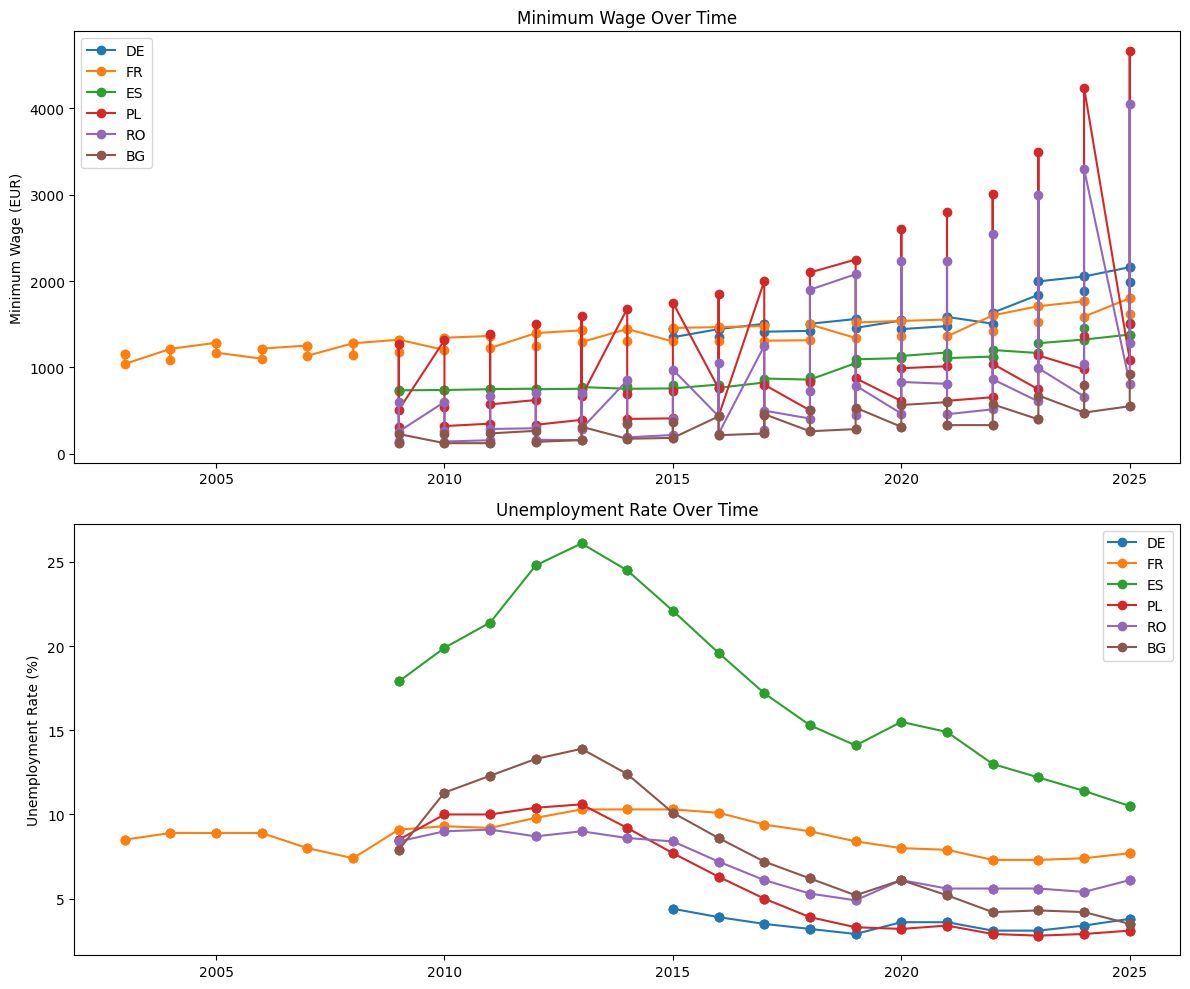

In [ ]:

selected = ['DE', 'FR', 'ES', 'PL', 'RO', 'BG']

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

for country in selected:
    data = panel_final[panel_final['geo'] == country].sort_values('year')
    ax1.plot(data['year'], data['min_wage_eur'], marker='o', label=country)
    ax2.plot(data['year'], data['unemployment_rate'], marker='o', label=country)

ax1.set_title('Minimum Wage Over Time')
ax1.set_ylabel('Minimum Wage (EUR)')
ax1.legend()

ax2.set_title('Unemployment Rate Over Time')
ax2.set_ylabel('Unemployment Rate (%)')
ax2.legend()

plt.tight_layout()
plt.show()


## 4. Regression Analysis
Run a simple linear regression to quantify the relationship between minimum wage and unemployment rate.


In [ ]:
from scipy import stats


slope, intercept, r_value, p_value, std_err = stats.linregress(
    panel_final['min_wage_eur'],
    panel_final['unemployment_rate']
)

print(f"slope (slope): {slope:.4f}")
print(f"intercept (intercept): {intercept:.4f}")
print(f"R² : {r_value**2:.4f}")
print(f"P_value (p-value): {p_value:.4f}")


slope (slope): -0.0030
intercept (intercept): 11.7065
R² : 0.1195
P_value (p-value): 0.0000


In [ ]:
from scipy import stats

slope, intercept, r_value, p_value, std_err = stats.linregress(
    panel_final['min_wage_eur'],
    panel_final['unemployment_rate']
)

print(f"Slope: {slope:.4f}")
print(f"Intercept: {intercept:.4f}")
print(f"R²: {r_value**2:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"\nInterpretation:")
print(f"A 1 EUR increase in minimum wage is associated with a {abs(slope):.4f} percentage point decrease in unemployment rate.")
print(f"The relationship is statistically significant (p < 0.05).")
print(f"Minimum wage explains {r_value**2*100:.1f}% of the variation in unemployment rate.")


Slope: -0.0030
Intercept: 11.7065
R²: 0.1195
P-value: 0.0000

Interpretation:
A 1 EUR increase in minimum wage is associated with a 0.0030 percentage point decrease in unemployment rate.
The relationship is statistically significant (p < 0.05).
Minimum wage explains 11.9% of the variation in unemployment rate.


In [ ]:
import plotly.express as px

fig = px.scatter(
    panel_final,
    x='min_wage_eur',
    y='unemployment_rate',
    color='geo',
    hover_data=['geo', 'year', 'min_wage_eur', 'unemployment_rate'],
    title='Minimum Wage vs Unemployment Rate in Europe (2003-2025)',
    labels={
        'min_wage_eur': 'Minimum Wage (EUR)',
        'unemployment_rate': 'Unemployment Rate (%)',
        'geo': 'Country'
    },
    trendline='ols'
)

fig.show()


## 5. Regional Analysis
Divide countries into geographical regions and analyze trends within each region.


In [ ]:
import plotly.express as px

panel_map = panel_final.copy()
panel_map['iso3'] = panel_map['geo'].map(iso2_to_iso3)
panel_map = panel_map.dropna(subset=['iso3'])

panel_map = panel_map.sort_values('year')
fig = px.choropleth(
    panel_map,
    locations='iso3',
    color='min_wage_eur',
    hover_name='geo',
    hover_data={'min_wage_eur': True, 'unemployment_rate': True},
    animation_frame='year',
    scope='europe',
    color_continuous_scale='RdYlGn',
    title='Minimum Wage in Europe Over Time',
    labels={'min_wage_eur': 'Minimum Wage (EUR)'},
    width=900,
    height=600,
    range_color=[0, panel_map['min_wage_eur'].max()]
)

fig.show()


In [ ]:
fig.write_html("minimum_wage_map.html")
print("saved！")


saved！


In [ ]:
from google.colab import files
files.download("minimum_wage_map.html")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:

region_map = {
    'Western Europe': ['BE', 'DE', 'FR', 'IE', 'LU', 'NL'],
    'Northern Europe': ['EE', 'LT', 'LV'],
    'Southern Europe': ['CY', 'EL', 'ES', 'HR', 'MT', 'PT', 'SI'],
    'Eastern Europe': ['BG', 'CZ', 'HU', 'MK', 'PL', 'RO', 'RS', 'SK'],
    'Other': ['ME', 'TR']
}


geo_to_region = {}
for region, countries in region_map.items():
    for country in countries:
        geo_to_region[country] = region

panel_final['region'] = panel_final['geo'].map(geo_to_region)

region_avg = panel_final.groupby(['region', 'year']).agg(
    min_wage_eur=('min_wage_eur', 'mean'),
    unemployment_rate=('unemployment_rate', 'mean')
).reset_index()

print(region_avg.head(10))


           region  year  min_wage_eur  unemployment_rate
0  Eastern Europe  2009    286.431259           8.866667
1  Eastern Europe  2010    263.800324          11.971429
2  Eastern Europe  2011    278.337375          12.471429
3  Eastern Europe  2012    293.256287          12.857143
4  Eastern Europe  2013    279.903687          14.700000
5  Eastern Europe  2014    299.845726          13.200000
6  Eastern Europe  2015    320.319821          11.812500
7  Eastern Europe  2016    341.067500          10.112500
8  Eastern Europe  2017    374.466524           8.787500
9  Eastern Europe  2018    440.096873           7.787500


In [ ]:
import plotly.express as px

fig1 = px.line(
    region_avg,
    x='year',
    y='min_wage_eur',
    color='region',
    title='Average Minimum Wage by Region Over Time',
    labels={'min_wage_eur': 'Minimum Wage (EUR)', 'year': 'Year', 'region': 'Region'}
)
fig1.show()

fig2 = px.line(
    region_avg,
    x='year',
    y='unemployment_rate',
    color='region',
    title='Average Unemployment Rate by Region Over Time',
    labels={'unemployment_rate': 'Unemployment Rate (%)', 'year': 'Year', 'region': 'Region'}
)
fig2.show()


In [ ]:

panel_final.to_csv('panel_data.csv', index=False)
region_avg.to_csv('region_data.csv', index=False)
print("saved！")

from google.colab import files
files.download('panel_data.csv')
files.download('region_data.csv')


saved！


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 6. Interactive Streamlit App
The interactive web application is built using Streamlit, allowing users to explore the data from different perspectives.

To run the app locally:
1. Download app.py, panel_data.csv, and region_data.csv
2. Install dependencies: pip install streamlit plotly pandas scipy
3. Run: streamlit run app.py

Features:
- Filter by region and year range
- Interactive scatter plot with trendline
- Regional trend visualizations


In [ ]:
!pip install streamlit pyngrok -q

app_code = """
import streamlit as st
import pandas as pd
import plotly.express as px
from scipy import stats

panel = pd.read_csv('panel_data.csv')
region_avg = pd.read_csv('region_data.csv')

st.title('Minimum Wage and Unemployment in Europe')

st.sidebar.header('Filters')
selected_region = st.sidebar.selectbox(
    'Select Region',
    ['All'] + sorted(panel['region'].dropna().unique().tolist())
)
selected_years = st.sidebar.slider(
    'Select Year Range',
    int(panel['year'].min()),
    int(panel['year'].max()),
    (2010, 2023)
)

filtered = panel[
    (panel['year'] >= selected_years[0]) &
    (panel['year'] <= selected_years[1])
]
if selected_region != 'All':
    filtered = filtered[filtered['region'] == selected_region]

st.subheader('Minimum Wage vs Unemployment Rate')
fig1 = px.scatter(filtered, x='min_wage_eur', y='unemployment_rate',
    color='geo', hover_data=['geo', 'year'], trendline='ols')
st.plotly_chart(fig1)

st.subheader('Trends by Region')
fig2 = px.line(region_avg, x='year', y='min_wage_eur', color='region')
st.plotly_chart(fig2)
fig3 = px.line(region_avg, x='year', y='unemployment_rate', color='region')
st.plotly_chart(fig3)
"""

with open('app.py', 'w') as f:
    f.write(app_code)

print("app.py created!")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 60.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 94.6 MB/s eta 0:00:00
app.py created!


In [ ]:
from google.colab import files
files.download('app.py')
files.download('panel_data.csv')
files.download('region_data.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 7. Conclusion

Our analysis finds a statistically significant negative correlation between minimum wage and unemployment rate across 26 European countries from 2003 to 2025 (slope = -0.003, R² = 0.12, p < 0.05).

This suggests that higher minimum wages are associated with lower unemployment rates, consistent with Card & Krueger (1994). However, minimum wage explains only 12% of the variation in unemployment rate, indicating that other factors such as GDP growth and economic cycles also play important roles.

Regional analysis shows that Western Europe consistently maintains the highest minimum wages and lowest unemployment rates, while Eastern and Southern Europe show greater volatility.
